<a href="https://colab.research.google.com/github/rochder1456-hue/Pr-cticas-de-programaci-n-/blob/main/EJEMPLO_PYTHON_PROPEDEUTICO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Primeras filas del dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Estadísticas univariantes:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Correlación entre v

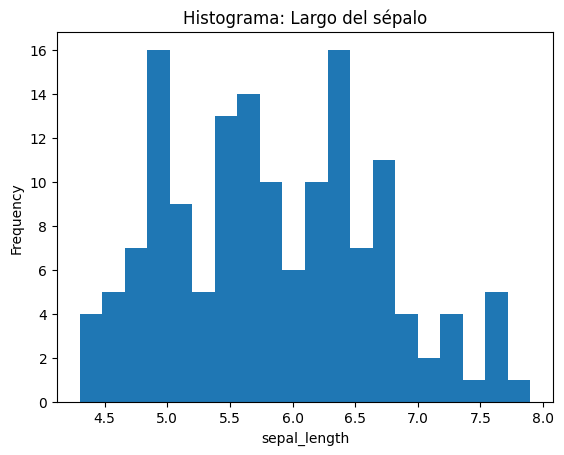

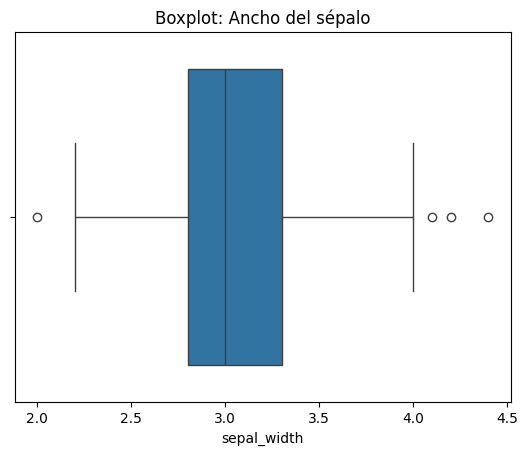

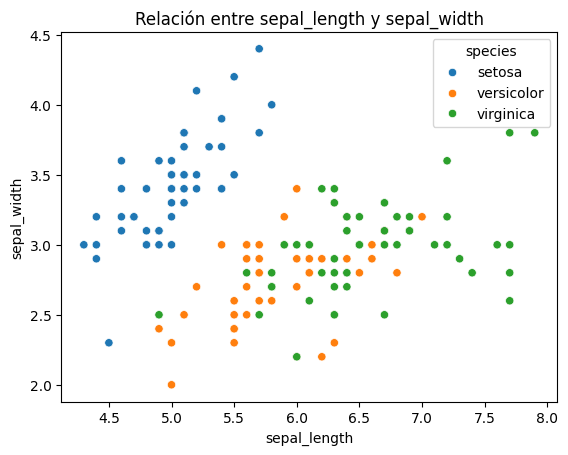

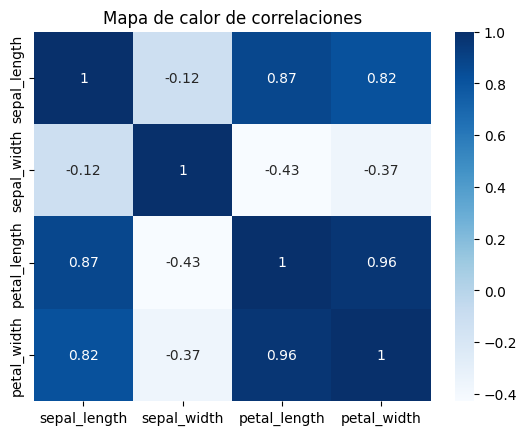

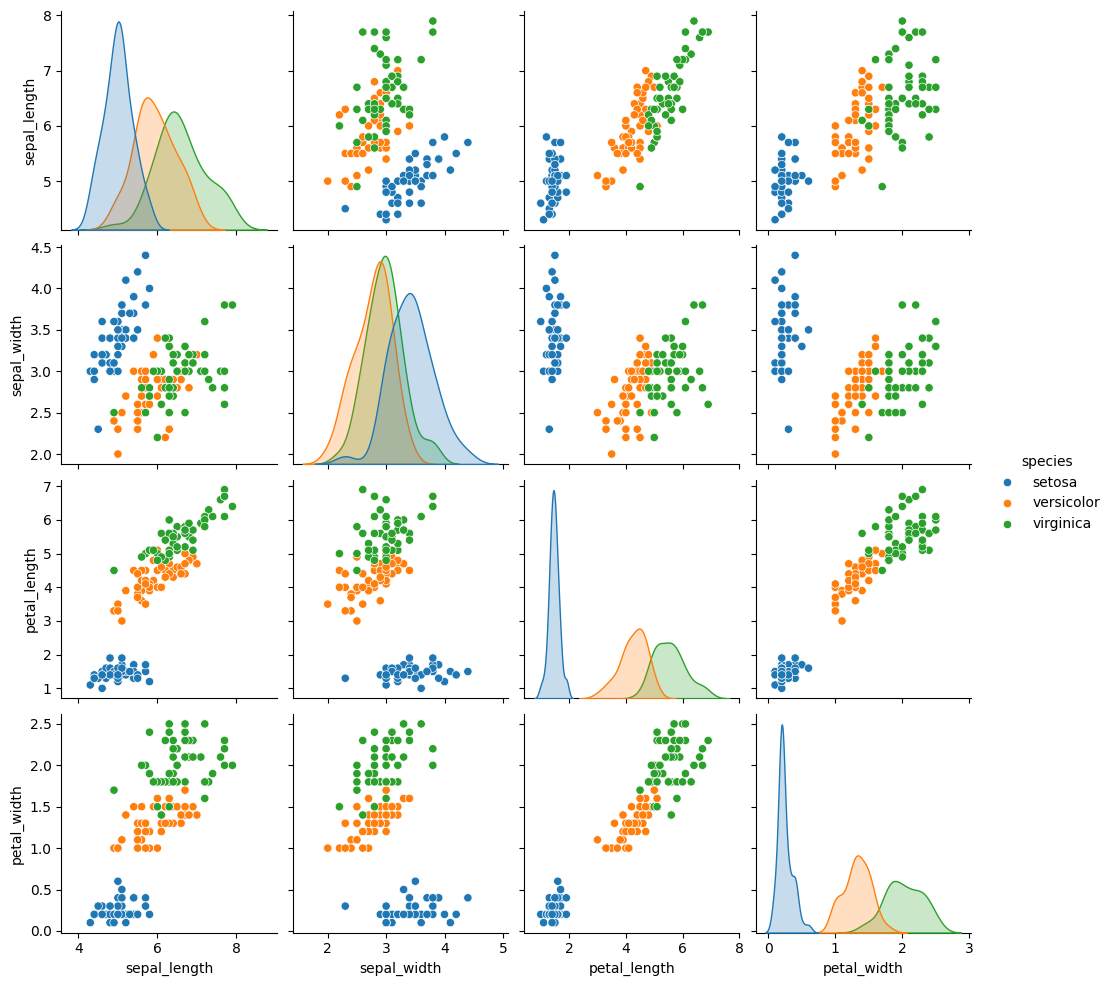


EDA completado. Gráficos guardados en el directorio de ejecución.


In [1]:
#Ejemplo del analisis exporatorio de datos (EDA) en Python
#-----------------------
#Importar nuestras librerías
#-----------------------
import pandas as pd #Tablas de datos
import seaborn as sns #Graficos estadisticos y datasets de ejemplo
import matplotlib.pyplot as plt #Guardar figuras
#-----------------------
#1 Cargar el dataset Iris
#-----------------------
#Cargar el dataset Iris de ejemplo, que contiene medidas de flores y especie
#
#Cargar el dataset 'iris' (incluido en seaborn) en un dataframe llamado 'df'
df = sns.load_dataset("iris")
print("Primeras filas del dataset:")
#Muestra las primeras 5 filas del dataframe para una dispersión rápida de los datos.
print(df.head())
#-----------------------
#2. EDA Univariable
#-----------------------
# Proporciona media, desviación estandar, rengos, etc. para variables numéricas
print("\nEstadísticas univariantes:")
print(df.describe())

plt.figure()

df["sepal_length"].plot(kind="hist", bins=20, title="Histograma: Largo del sépalo")
plt.xlabel("sepal_length")
plt.savefig("histograma_sepal_length.png")

plt.figure()

sns.boxplot(data=df, x="sepal_width")
plt.title("Boxplot: Ancho del sépalo")
plt.savefig("boxplot_sepal_width.png")

plt.figure()

sns.scatterplot(data=df, x="sepal_length", y="sepal_width", hue="species")
plt.title("Relación entre sepal_length y sepal_width")
plt.savefig("scatterplot_sepal.png")

print("\nCorrelación entre variables numéricas:")
print(df.corr(numeric_only=True))

plt.figure()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Mapa de calor de correlaciones")
plt.savefig("heatmap_correlaciones.png")

sns.pairplot(df, hue="species")
plt.savefig("pairplot_iris.png")

print("\nMedia de variables por especie:")
print(df.groupby("species").mean())
plt.show()
print("\nEDA completado. Gráficos guardados en el directorio de ejecución.")

In [ ]:
!pip install squarify

TABLA DE VENTAS POR REGIÓN Y CATEGORÍA
  region  categoria_A  categoria_B  categoria_C
0  Norte          100           50           30
1    Sur           80           60           40
2   Este           60           70           50
3  Oeste           40           80           60


/tmp/ipython-input-4237435626.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  meses = pd.date_range("2024-01-01", periods=6, freq="M")


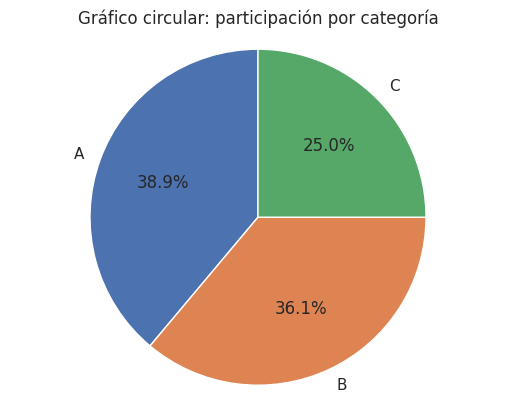

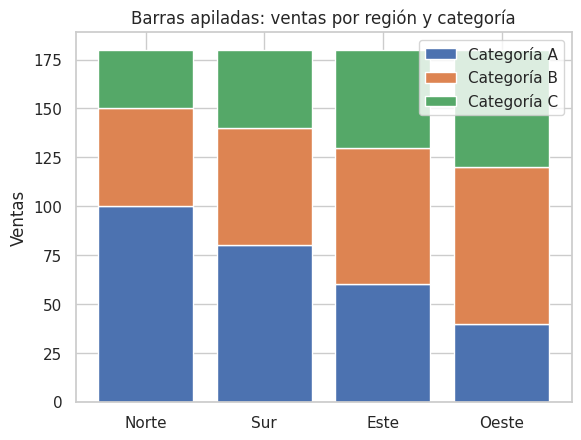

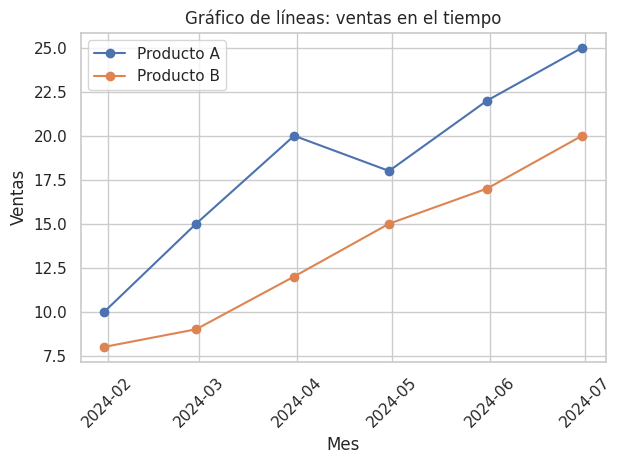

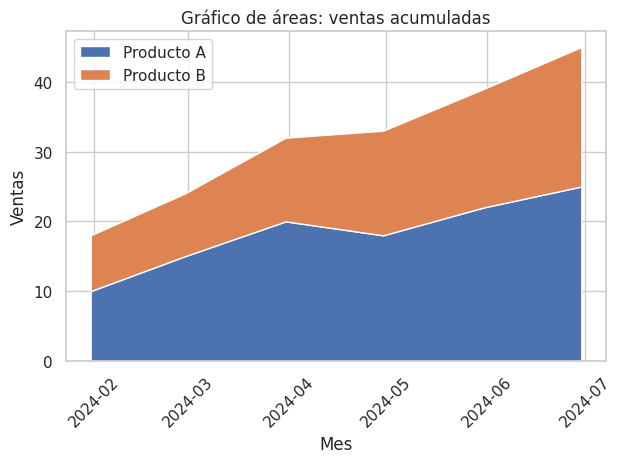

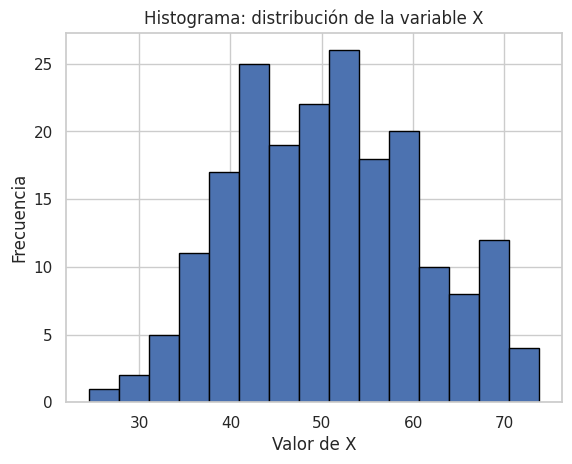

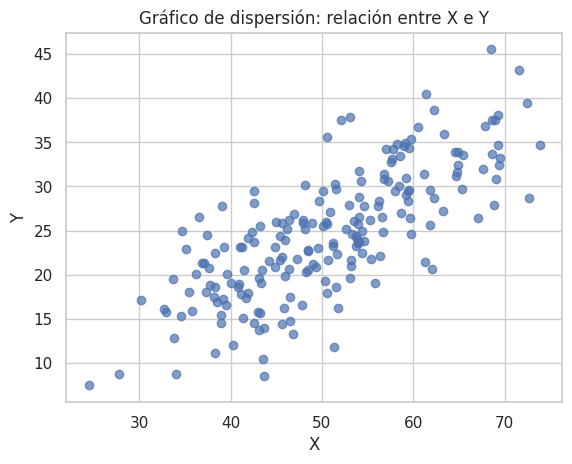

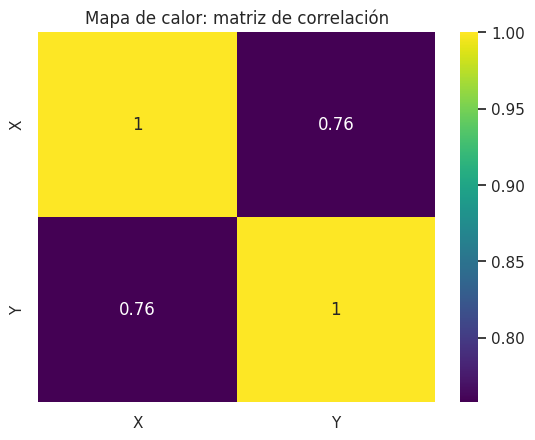

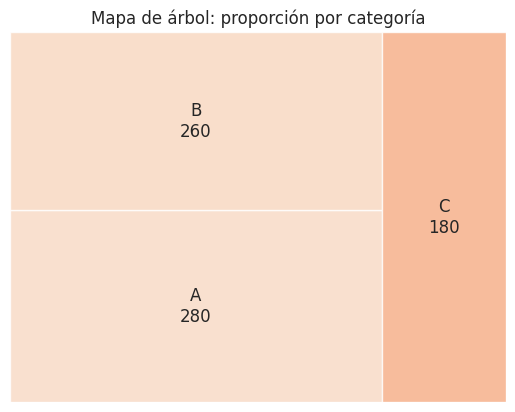

In [ ]:
#Importar las librerías
#-------------
import pandas as pd # Manipulación de datos
import numpy as np # Simular variables contínuas con ruido
import matplotlib.pyplot as plt  # Crear gráficos
import seaborn as sns # Crear gráficos estadísticos
import squarify  #Mapa de arbol

sns.set(style="whitegrid")

# Se crea una tabla con ventas por región en 3 categorías (A, B, C).
datos = {
    "region": ["Norte", "Sur", "Este", "Oeste"],
    "categoria_A": [100, 80, 60, 40],
    "categoria_B": [50, 60, 70, 80],
    "categoria_C": [30, 40, 50, 60],
}
df = pd.DataFrame(datos)

#Se crea una tabla con ventas de dos productos a lo largo de 6 meses.

meses = pd.date_range("2024-01-01", periods=6, freq="M")
ventas_tiempo = pd.DataFrame({
    "mes": meses,
    "producto_A": [10, 15, 20, 18, 22, 25],
    "producto_B": [8, 9, 12, 15, 17, 20]
})

# Simular datos para visualizar distribuciones y relaciones
np.random.seed(0)
x = np.random.normal(50, 10, 200)
y = x * 0.5 + np.random.normal(0, 5, 200)

print("TABLA DE VENTAS POR REGIÓN Y CATEGORÍA")
print(df)

#gráfico Circular
totales_categoria = {
    "A": df["categoria_A"].sum(),
    "B": df["categoria_B"].sum(),
    "C": df["categoria_C"].sum(),
}

# Muestra la proporción total de ventas por categoría sumando todas las regiones
plt.figure()
plt.title("Gráfico circular: participación por categoría")

plt.pie(totales_categoria.values(),
        labels=totales_categoria.keys(),
        autopct="%1.1f%%",
        startangle=90)
plt.axis("equal")
plt.show()

# Barras Apiladas
plt.figure()
plt.title("Barras apiladas: ventas por región y categoría")
plt.bar(df["region"], df["categoria_A"], label="Categoría A")
plt.bar(df["region"], df["categoria_B"], bottom=df["categoria_A"], label="Categoría B")
# Se muestran las ventas por región, pero apilando las categorías A, B, y C para comparar proporciones
plt.bar(df["region"], df["categoria_C"],
        bottom=df["categoria_A"] + df["categoria_B"], label="Categoría C")
plt.ylabel("Ventas")
plt.legend()
plt.show()

plt.figure()
plt.plot(ventas_tiempo["mes"], ventas_tiempo["producto_A"], marker="o", label="Producto A")

plt.plot(ventas_tiempo["mes"], ventas_tiempo["producto_B"], marker="o", label="Producto B")
plt.title("Gráfico de líneas: ventas en el tiempo")
plt.xlabel("Mes"); plt.ylabel("Ventas")
plt.legend(); plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.stackplot(
    ventas_tiempo["mes"],
    ventas_tiempo["producto_A"],
    ventas_tiempo["producto_B"],
    labels=["Producto A", "Producto B"]
)
# Gráfico de Líneas y áreas Muestra la distribución de la variable X (valores aleatorios)
plt.title("Gráfico de áreas: ventas acumuladas")
plt.xlabel("Mes"); plt.ylabel("Ventas")
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Histograma
plt.figure()
plt.title("Histograma: distribución de la variable X")
plt.hist(x, bins=15, edgecolor="black")
plt.xlabel("Valor de X"); plt.ylabel("Frecuencia")
plt.show()
# Gráfico de dispersión
plt.figure()
plt.title("Gráfico de dispersión: relación entre X e Y")
plt.scatter(x, y, alpha=0.7)
plt.xlabel("X"); plt.ylabel("Y")
plt.show()

df_xy = pd.DataFrame({"X": x, "Y": y})
corr = df_xy.corr()
plt.figure()
sns.heatmap(corr, annot=True, cmap="viridis")
plt.title("Mapa de calor: matriz de correlación")
plt.show()

sizes = list(totales_categoria.values())
labels = [f"{cat}\n{val}" for cat, val in totales_categoria.items()]

plt.figure()
plt.title("Mapa de árbol: proporción por categoría")
squarify.plot(sizes=sizes, label=labels, alpha=0.8)
plt.axis("off")
plt.show()